# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Identify the top 5 counties with the highest number of collisions.</br>
    4.2. Identify the month with the highest number of collisions.</br>
    4.3. Determine the most common weather condition during collisions.</br>
    4.4. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.5. Find the most dangerous time of day for collisions.</br>
    4.6. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.7. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [24]:
#from google.colab import drive
#drive.mount('/content/drive')

Install Required Libraries

In [25]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [26]:
# Import the necessary libraries
import sqlite3
import pandas as pd

import os
import sys
import warnings
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, max, count, when, to_date

# Ensure PySpark uses the active virtual environment's Python to prevent version mismatches
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable
os.environ['JAVA_HOME'] = "/Library/Java/JavaVirtualMachines/openjdk-17.jdk/Contents/Home"

# Initialize Spark Session and silence Log4j Java warnings
spark = SparkSession.builder \
    .appName("Bank Data Analysis") \
    .getOrCreate()
    

warnings.filterwarnings('ignore')
spark.sparkContext.setLogLevel("ERROR")

print("Spark Session successfully initialized!")

Spark Session successfully initialized!


#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [27]:
# Write code to load the data and check the schema

collisions = spark.read.csv("sample_collisions.csv", header=True, inferSchema=True)
parties = spark.read.csv("sample_parties.csv", header=True, inferSchema=True)
victims = spark.read.csv("sample_victims.csv", header=True, inferSchema=True)
case_ids = spark.read.csv("sample_case_ids.csv", header=True, inferSchema=True)


# Display sample data
collisions.show(5)
parties.show(5)
victims.show(5)
case_ids.show(5)

#Schema
collisions.printSchema()
parties.printSchema()
victims.printSchema()
case_ids.printSchema()


+-----------+------------+----------+------------------+--------------+----------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+------------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+---------------+-----------------+---------------------------+--------------------+------------+----------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+---

#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [28]:
#Display Schema & Sample Data

# Display sample data
collisions.show(5)
parties.show(5)
victims.show(5)
case_ids.show(5)

# Display schema
collisions.printSchema()
parties.printSchema()
victims.printSchema()
case_ids.printSchema()

+-----------+------------+----------+------------------+--------------+----------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+------------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+---------------+-----------------+---------------------------+--------------------+------------+----------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+---

##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [29]:
#Check for Missing Values
collisions.select([
    count(when(col(c).isNull(), c)).alias(c) for c in collisions.columns
]).show()

parties.select([
    count(when(col(c).isNull(), c)).alias(c) for c in parties.columns
]).show()

victims.select([
    count(when(col(c).isNull(), c)).alias(c) for c in victims.columns
]).show()

case_ids.select([
    count(when(col(c).isNull(), c)).alias(c) for c in case_ids.columns
]).show()

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

+---+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+------------------------+----------------+------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+
| id|case_id|party_number|party_type|at_fault|party_sex|party_age|party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year|vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|
+---+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+-------------------

In [30]:
#Drop Sparse Columns

collisions.count()
collisions.select([count(col(c)).alias(c) for c in collisions.columns]).show()

parties.count()
parties.select([count(col(c)).alias(c) for c in parties.columns]).show()

victims.count()
victims.select([count(col(c)).alias(c) for c in victims.columns]).show()

case_ids.count()
case_ids.select([count(col(c)).alias(c) for c in case_ids.columns]).show()

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

+-------+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+------------------------+----------------+------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+
|     id|case_id|party_number|party_type|at_fault|party_sex|party_age|party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year|vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|
+-------+-------+------------+----------+--------+---------+---------+--------------+-------------------+------------------------+------------------------+-------

In [31]:
#Convert Data Types
collisions = collisions.withColumn(
    "collision_date",
    to_date(col("collision_date"))
)

collisions = collisions.withColumn(
    "collision_time",
    col("collision_time").cast("string")
)

victims = victims.withColumn(
    "victim_age",
    col("victim_age").cast("int")
)

In [32]:
#Handle Missing Values
# Fill missing values in collisions
collisions = collisions.fillna({
    "weather_1": "Unknown",
    "lighting": "Unknown",
    "road_surface": "Unknown"
})

# Fill missing values in victims
victims = victims.fillna({
    "victim_age": 0
})

# Fill missing values in parties
parties = parties.fillna("Unknown")

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [33]:
#Remove Duplicates
print("Collisions:", collisions.count())
collisions = collisions.dropDuplicates()
print("Collisions after duplicate removal:", collisions.count())

print("Parties:", parties.count())
parties = parties.dropDuplicates()
print("Parties after duplicate removal:", parties.count())

print("Victims:", victims.count())
victims = victims.dropDuplicates()
print("Victims after duplicate removal:", victims.count())

print("Case IDs:", case_ids.count())
case_ids = case_ids.dropDuplicates()
print("Case IDs after duplicate removal:", case_ids.count())

Collisions: 935791


Collisions after duplicate removal: 935791
Parties: 1866917


Parties after duplicate removal: 1866917
Victims: 963933
Victims after duplicate removal: 963933
Case IDs: 942433
Case IDs after duplicate removal: 942398


In [34]:
#Detect Outliers using IQR
# IQR for victim_age
quantiles = victims.approxQuantile("victim_age", [0.25, 0.75], 0)
Q1 = quantiles[0]
Q3 = quantiles[1]
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
# Show outliers
victims.filter((col("victim_age") < lower) | (col("victim_age") > upper)).show()

# Party age (only if column exists)
quantiles = parties.approxQuantile("party_age", [0.25, 0.75], 0)
Q1, Q3 = quantiles
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
# Show outliers
parties.filter((col("party_age") < lower) | (col("party_age") > upper)).show()

#IQR for longitude (collisions)
quantiles = collisions.approxQuantile("latitude", [0.25, 0.75], 0)
Q1 = quantiles[0]
Q3 = quantiles[1]
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
collisions.filter((col("latitude") < lower) | (col("latitude") > upper)).show()

# IQR for longitude (collisions)
quantiles = collisions.approxQuantile("longitude", [0.25, 0.75], 0)
Q1 = quantiles[0]
Q3 = quantiles[1]
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
# Show outliers
collisions.filter((col("longitude") < lower) | (col("longitude") > upper)).show()


# List of numerical columns to check for outliers
victim_numeric_cols = ["victim_age"]
collision_numeric_cols = ["latitude", "longitude"]

+-------+---------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|     id|  case_id|party_number|victim_role|victim_sex|victim_age|victim_degree_of_injury|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|
+-------+---------+------------+-----------+----------+----------+-----------------------+-----------------------+-------------------------+-------------------------+--------------+
|2117847|6279341.0|           1|  passenger|      male|        91|      complaint of pain|     station wagon rear|     air bag not deployed|     passive restraint...|   not ejected|
|3009685|7151472.0|           1|  passenger|      male|        92|          severe injury|       passenger seat 3|         air bag deployed|     lap/shoulder harn...|   not ejected|
|4004988|8999934.0|           1|  passenger|      male|        95|   other visible injury|

+--------+-----------+------------+----------+--------+---------+---------+--------------------+-------------------+------------------------+------------------------+------------------------+----------------+--------------------+------------------------+-------------------+--------------------+----------------------------+------------+-------------+----------------------+-----------------------+----------------------+----------+
|      id|    case_id|party_number|party_type|at_fault|party_sex|party_age|      party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|  cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year| vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|
+--------+-----------+------------+----------+--------+---------+---------+--------------------+-------------------+------------------

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-----------------------+-----------

##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [35]:
# Remove unrealistic ages
victims = victims.filter(
    (col("victim_age") >= 0) & (col("victim_age") <= 100)
)

# Remove unrealistic ages in parties
parties = parties.filter(
    (col("party_age") >= 0) & (col("party_age") <= 100)
)

# Keep only valid coordinates
collisions = collisions.filter(
    (col("latitude") >= -90) & (col("latitude") <= 90)
)

collisions = collisions.filter(
    (col("longitude") >= -180) & (col("longitude") <= 180)
)

#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [36]:
# Encode Categorical Variables
# String Indexing for Categorical Columns

#collisions
collisions.select("collision_severity").distinct().show()
collisions.select("weather_1").distinct().show()
collisions.select("lighting").distinct().show()

collisions = collisions \
.withColumn("collision_severity_encoded",
    when(col("collision_severity") == "property damage only", 1)
    .when(col("collision_severity") == "pain", 2)
    .when(col("collision_severity") == "other injury", 2)
    .when(col("collision_severity") == "severe injury", 2)
    .otherwise(5)
) \
.withColumn("weather_encoded",
    when(col("weather_1") == "fog", 1)
    .when(col("weather_1") == "raining", 2)
    .when(col("weather_1") == "clear", 3)
    .when(col("weather_1") == "cloudy", 4)
    .when(col("weather_1") == "wind", 5)
    .when(col("weather_1") == "snowing", 6)
    .otherwise(7)
) \
.withColumn("lighting_encoded",
    when(col("lighting") == "dark with street lights", 1)
    .when(col("lighting") == "dusk or dawn", 2)
    .otherwise(3)
)

#victims
victims.select("victim_degree_of_injury").distinct().show()
victims = victims.withColumn(
    "injury_encoded",
    when(col("victim_degree_of_injury") == "killed", 1)
    .when(col("victim_degree_of_injury") == "severe injury", 2)
    .when(col("victim_degree_of_injury") == "suspected serious injury", 3)
    .when(col("victim_degree_of_injury") == "other visible injury", 4)
    .when(col("victim_degree_of_injury") == "suspected minor injury", 5)
    .when(col("victim_degree_of_injury") == "possible injury", 6)
    .when(col("victim_degree_of_injury") == "complaint of pain", 7)
    .when(col("victim_degree_of_injury") == "no injury", 8)
    .otherwise(0)
)


#Parties 
parties.select("party_type").distinct().show()
parties = parties.withColumn(
    "party_type_encoded",
    when(col("party_type") == "driver", 1).otherwise(2)
)

+--------------------+
|  collision_severity|
+--------------------+
|property damage only|
|                pain|
|        other injury|
|       severe injury|
+--------------------+

+---------+
|weather_1|
+---------+
|      fog|
|  raining|
|    other|
|  Unknown|
|    clear|
|   cloudy|
|     wind|
|  snowing|
+---------+

+--------------------+
|            lighting|
+--------------------+
|dark with no stre...|
|dark with street ...|
|             Unknown|
|            daylight|
|dark with street ...|
|        dusk or dawn|
+--------------------+

+-----------------------+
|victim_degree_of_injury|
+-----------------------+
|   other visible injury|
|   suspected serious...|
|        possible injury|
|   suspected minor i...|
|      complaint of pain|
|              no injury|
|          severe injury|
|                 killed|
+-----------------------+

+--------------+
|    party_type|
+--------------+
|    pedestrian|
|     bicyclist|
|         other|
|       Unknown|
|      

In [37]:
# Reordering & Renaming Columns

collisions = collisions \
.withColumnRenamed("weather_1", "weather") \
.withColumnRenamed("road_surface", "road_condition")


victims = victims \
.withColumnRenamed("victim_age", "age") \
.withColumnRenamed("victim_degree_of_injury", "injury_level")

parties = parties \
.withColumnRenamed("party_type", "party_type") \
.withColumnRenamed("party_age", "age")


In [38]:
# Final cleaned data

print("Final Cleaned Collisions Data")
collisions.show(5)

print("Final Cleaned Parties Data")
parties.show(5)

print("Final Cleaned Victims Data")
victims.show(5)

print("Final Cleaned Case IDs Data")
case_ids.show(5)

Final Cleaned Collisions Data


+---------+------------+----------+------------------+--------------+---------------+--------------------+---------------+-----------------+-----------------+-------------+--------------+-----------+------------+--------------------+--------+---------+------------+-------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+---------------+-----------------+---------------------------+--------------------+--------------+----------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+-----------

+-------+-----------+------------+----------+--------+---------+----+--------------------+-------------------+------------------------+------------------------+------------------------+----------------+--------------------+------------------------+-------------------+--------------------+----------------------------+------------+------------+----------------------+-----------------------+----------------------+----------+------------------+
|     id|    case_id|party_number|party_type|at_fault|party_sex| age|      party_sobriety|direction_of_travel|party_safety_equipment_1|party_safety_equipment_2|financial_responsibility|cellphone_in_use|  cellphone_use_type|other_associate_factor_1|party_number_killed|party_number_injured|movement_preceding_collision|vehicle_year|vehicle_make|statewide_vehicle_type|chp_vehicle_type_towing|chp_vehicle_type_towed|party_race|party_type_encoded|
+-------+-----------+------------+----------+--------+---------+----+--------------------+-------------------+

+-------+-----------+------------+-----------+----------+---+---------------+-----------------------+-------------------------+-------------------------+--------------+--------------+
|     id|    case_id|party_number|victim_role|victim_sex|age|   injury_level|victim_seating_position|victim_safety_equipment_1|victim_safety_equipment_2|victim_ejected|injury_encoded|
+-------+-----------+------------+-----------+----------+---+---------------+-----------------------+-------------------------+-------------------------+--------------+--------------+
| 890114|  5028842.0|           1|  passenger|    female| 51|      no injury|       passenger seat 4|     air bag not deployed|     lap/shoulder harn...|   not ejected|             8|
|4691080|9.0908582E7|           1|     driver|      male| 81|possible injury|                 driver|         air bag deployed|     lap/shoulder harn...|   not ejected|             6|
|3463321|  8449777.0|           3|  passenger|    female|  0|      no injury|   

Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

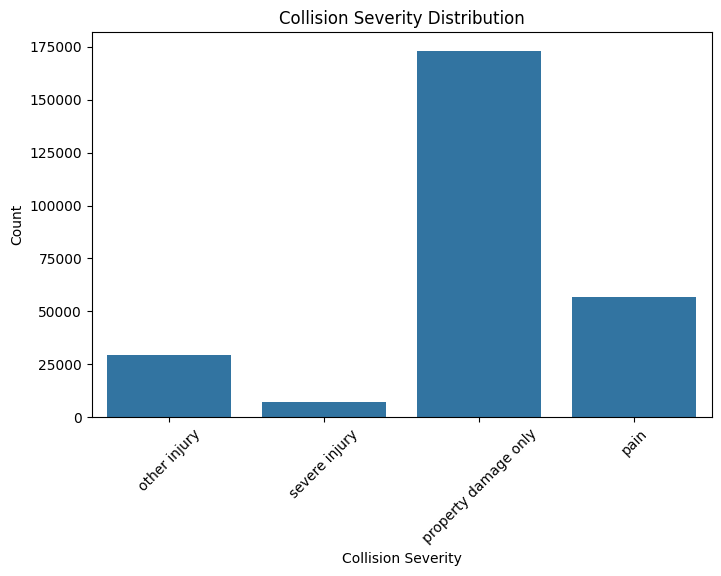

In [39]:
# Univariate Analysis

# Collision Severity Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas
df_pd = collisions.toPandas()

# Plot
plt.figure(figsize=(8,5))

sns.countplot(x='collision_severity', data=df_pd)

plt.title("Collision Severity Distribution")
plt.xlabel("Collision Severity")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

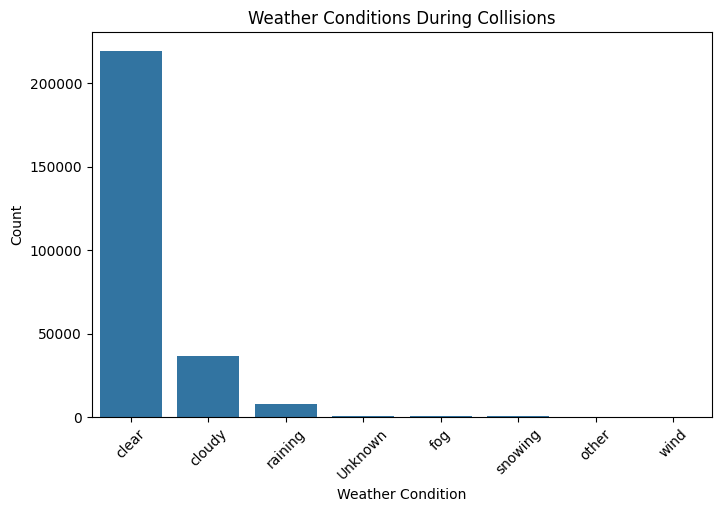

In [40]:
# Weather Conditions During Collisions

# Convert to Pandas

# Plot

plt.figure(figsize=(8,5))

sns.countplot(x='weather', data=df_pd)

plt.title("Weather Conditions During Collisions")
plt.xlabel("Weather Condition")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

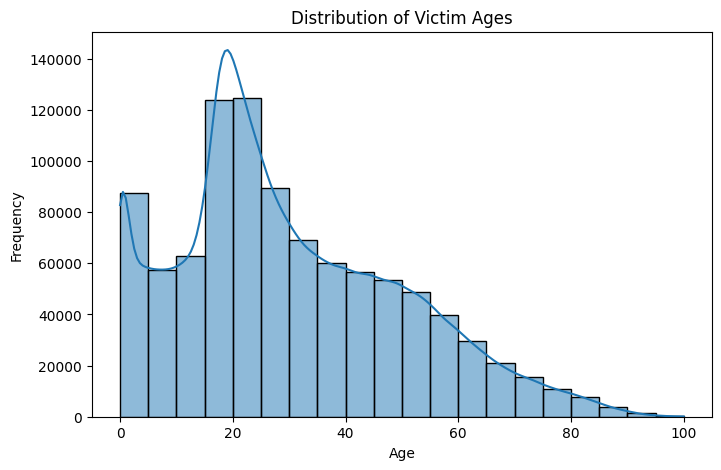

In [41]:
# Distribution of Victim Ages

# Convert to Pandas

# Plot

victims_pd = victims.toPandas()

plt.figure(figsize=(8,5))

sns.histplot(victims_pd['age'], bins=20, kde=True)

plt.title("Distribution of Victim Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

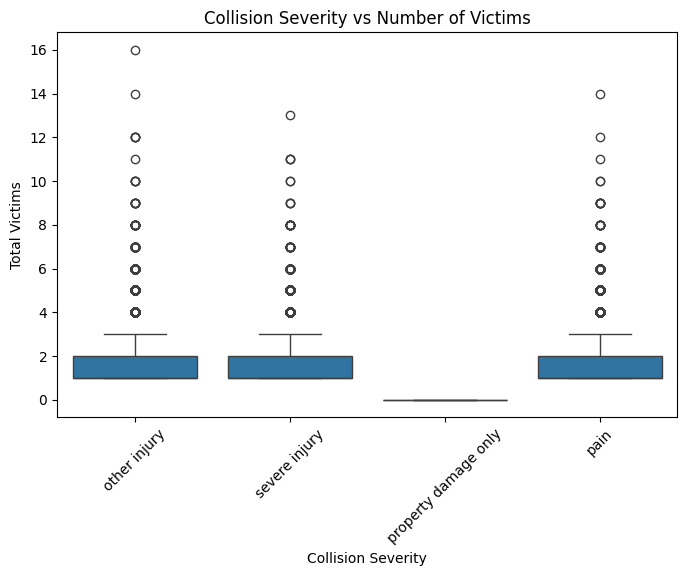

In [42]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims

# Convert to Pandas

# Plot

# Create total victims column
df_pd['total_victims'] = df_pd['killed_victims'] + df_pd['injured_victims']

plt.figure(figsize=(8,5))

sns.boxplot(x='collision_severity', y='total_victims', data=df_pd)

plt.title("Collision Severity vs Number of Victims")
plt.xlabel("Collision Severity")
plt.ylabel("Total Victims")

plt.xticks(rotation=45)

plt.show()

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

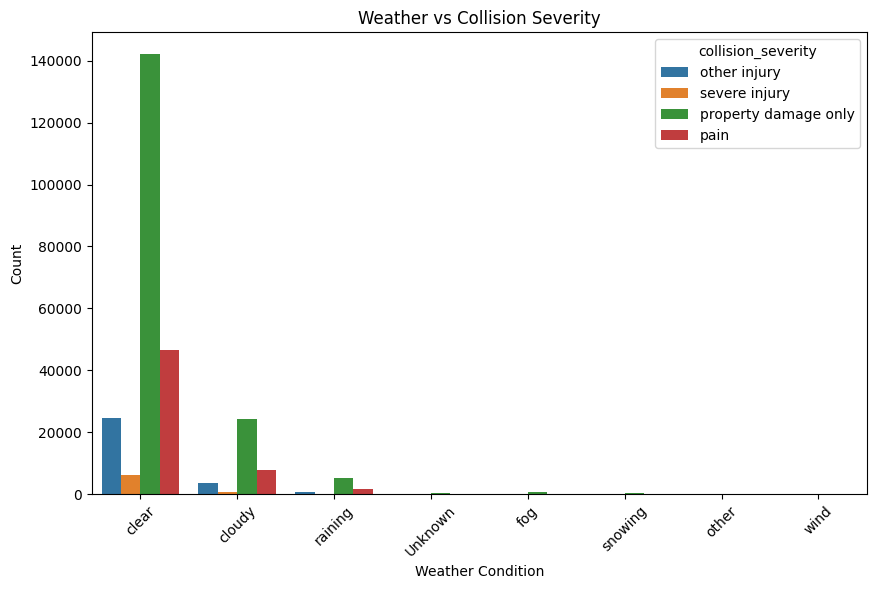

In [43]:
# Weather vs. Collision Severity

# Convert to Pandas

# Plot

plt.figure(figsize=(10,6))

sns.countplot(x='weather', hue='collision_severity', data=df_pd)

plt.title("Weather vs Collision Severity")
plt.xlabel("Weather Condition")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

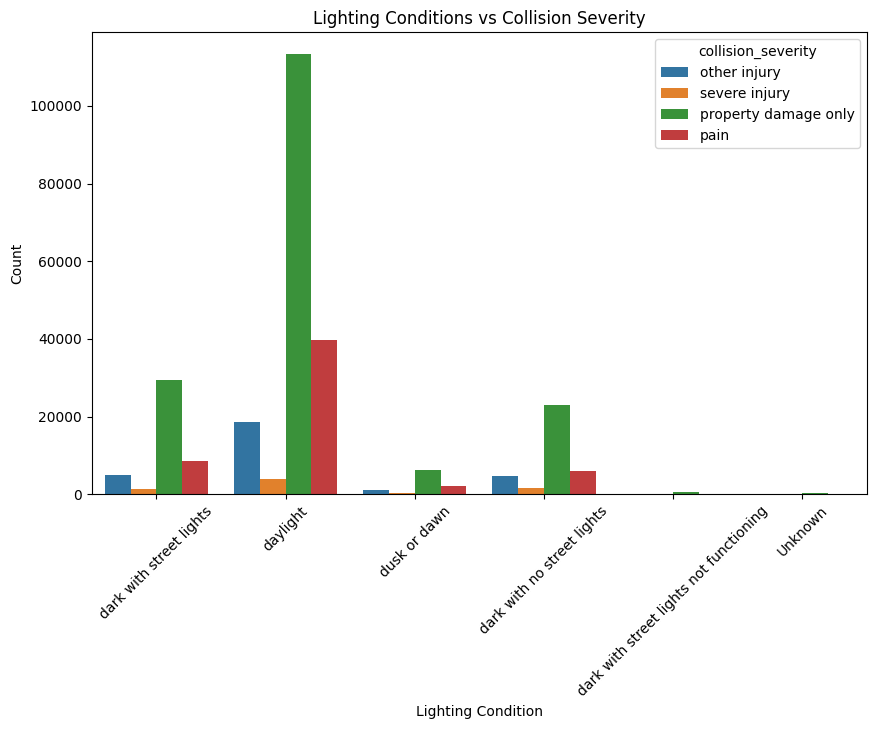

In [44]:
# Lighting Conditions vs. Collision Severity

# Convert to Pandas

# Plot


plt.figure(figsize=(10,6))

sns.countplot(x='lighting', hue='collision_severity', data=df_pd)

plt.title("Lighting Conditions vs Collision Severity")
plt.xlabel("Lighting Condition")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

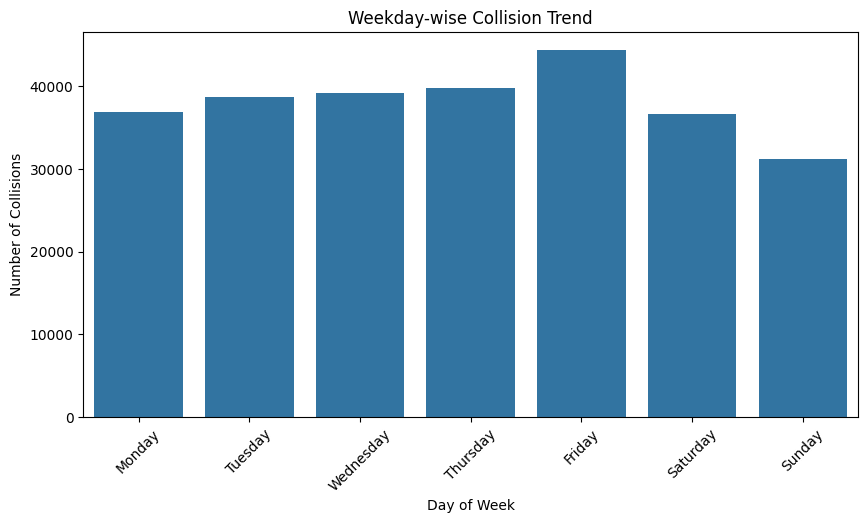

In [45]:
# Extract the weekday

# Plot

df_pd['collision_date'] = pd.to_datetime(df_pd['collision_date'])
df_pd['weekday'] = df_pd['collision_date'].dt.day_name()

plt.figure(figsize=(10,5))

sns.countplot(x='weekday', data=df_pd,
              order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

plt.title("Weekday-wise Collision Trend")
plt.xlabel("Day of Week")
plt.ylabel("Number of Collisions")

plt.xticks(rotation=45)

plt.show()

##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

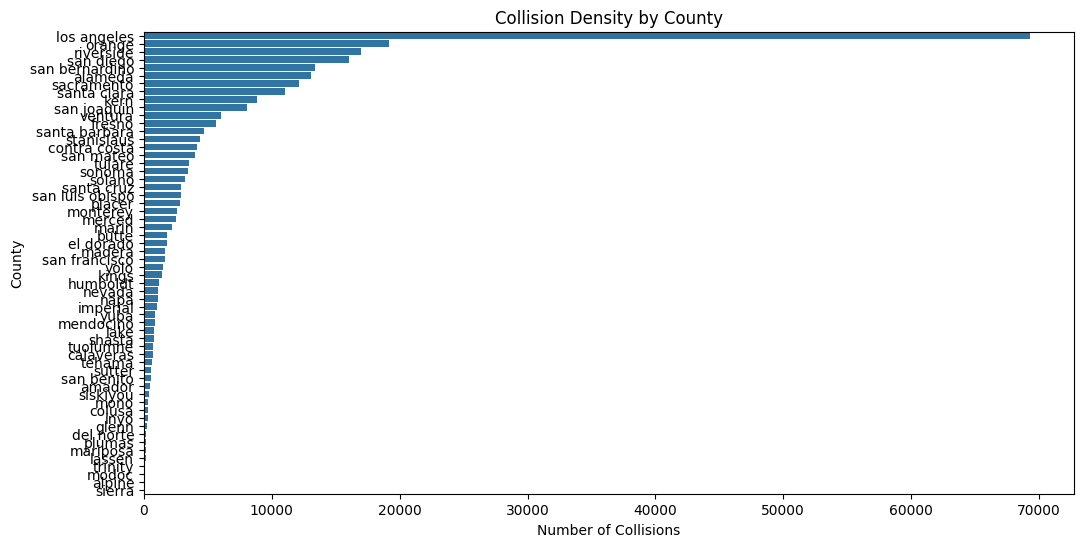

In [46]:
# Spatial Analysis

# Collision Density by County

# Plot the map

plt.figure(figsize=(12,6))

sns.countplot(y='county_location', data=df_pd,
              order=df_pd['county_location'].value_counts().index)

plt.title("Collision Density by County")
plt.xlabel("Number of Collisions")
plt.ylabel("County")

plt.show()

##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

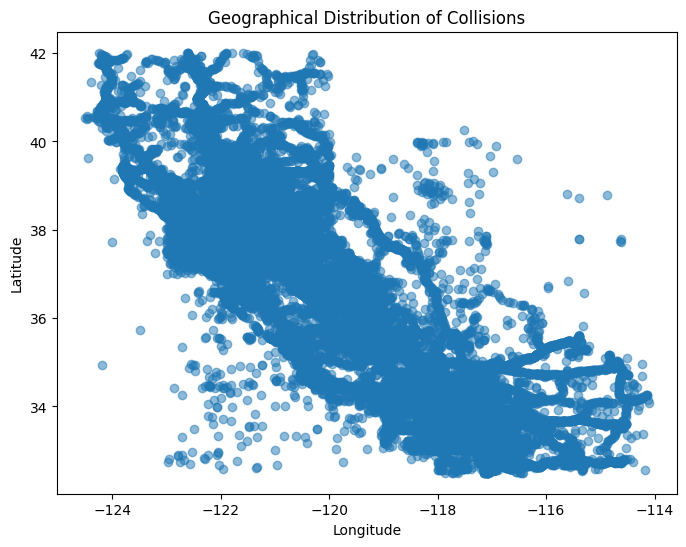

In [47]:
# Scatter Plot of Collision Locations

# Convert PySpark DataFrame to Pandas, handling potential missing values

# Convert to numeric (if needed) and handle invalid data

# Plot the scatter plot


# Convert to numeric (handle invalid values)
df_pd['latitude'] = pd.to_numeric(df_pd['latitude'], errors='coerce')
df_pd['longitude'] = pd.to_numeric(df_pd['longitude'], errors='coerce')

# Drop missing values
df_pd = df_pd.dropna(subset=['latitude', 'longitude'])

plt.figure(figsize=(8,6))

plt.scatter(df_pd['longitude'], df_pd['latitude'], alpha=0.5)

plt.title("Geographical Distribution of Collisions")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [48]:
from pyspark.sql.functions import year, month, hour, to_timestamp, col

# Extract year and month from collision_date

# Plot


df_pd['collision_date'] = pd.to_datetime(df_pd['collision_date'])

df_pd['year'] = df_pd['collision_date'].dt.year
df_pd['month'] = df_pd['collision_date'].dt.month

df_pd['collision_time'] = pd.to_datetime(df_pd['collision_time'], errors='coerce')
df_pd['hour'] = df_pd['collision_time'].dt.hour

Q: Analyze yearly, monthly and hourly trends in collisions.

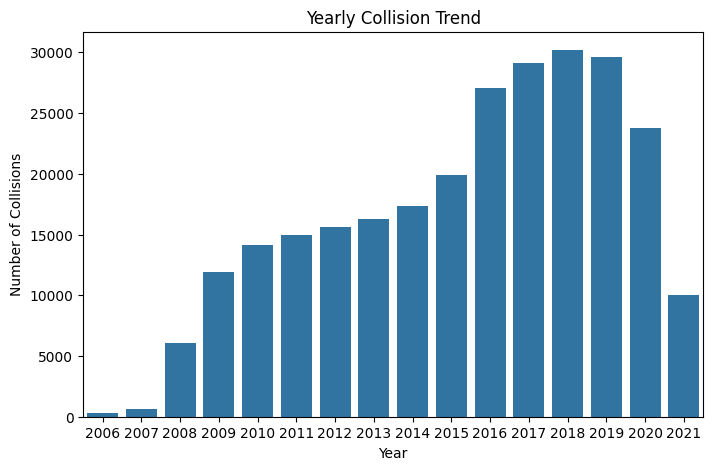

In [49]:
# Yearly Trend of Collisions

# Plot

plt.figure(figsize=(8,5))

sns.countplot(x='year', data=df_pd)

plt.title("Yearly Collision Trend")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")

plt.show()

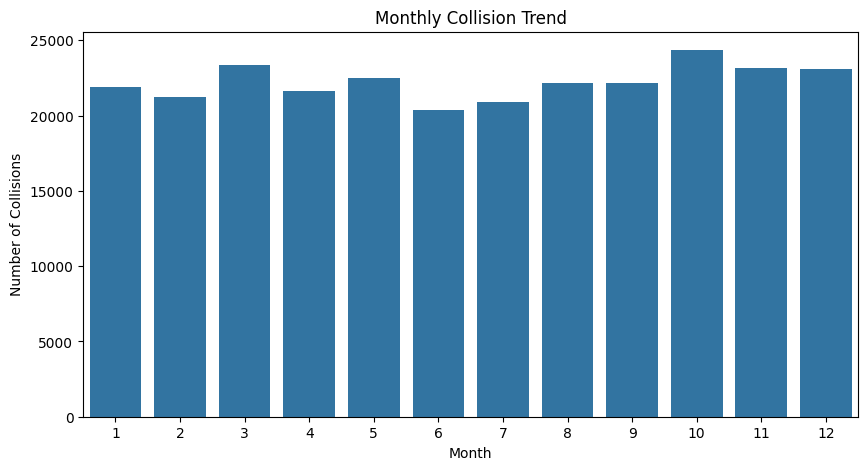

In [50]:
# Monthly Trend of Collisions

# Plot

plt.figure(figsize=(10,5))

sns.countplot(x='month', data=df_pd)

plt.title("Monthly Collision Trend")
plt.xlabel("Month")
plt.ylabel("Number of Collisions")

plt.show()

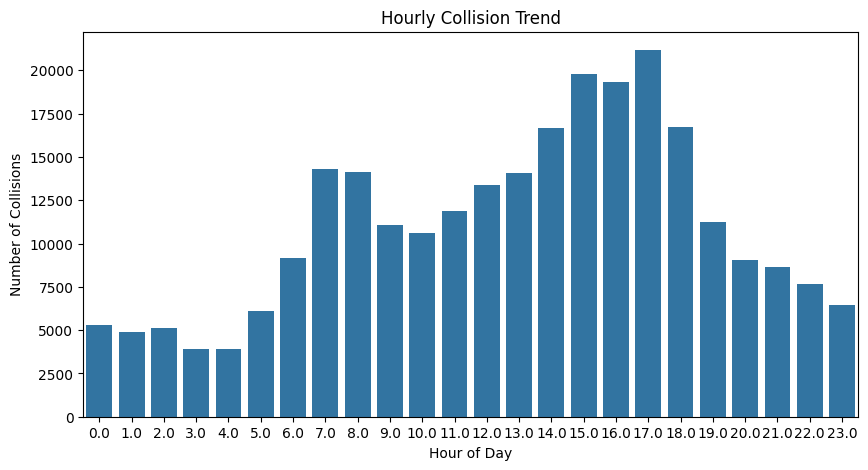

In [51]:
# Hourly Trend of Collisions

# Plot

plt.figure(figsize=(10,5))

sns.countplot(x='hour', data=df_pd)

plt.title("Hourly Collision Trend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")

plt.show()

#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [52]:
# Query: Identify the top 5 counties with the most collisions

from pyspark.sql.functions import count, desc

collisions.groupBy("county_location") \
    .agg(count("*").alias("total_collisions")) \
    .orderBy(desc("total_collisions")) \
    .show(5)

+---------------+----------------+
|county_location|total_collisions|
+---------------+----------------+
|    los angeles|           69264|
|         orange|           19199|
|      riverside|           16965|
|      san diego|           16036|
| san bernardino|           13406|
+---------------+----------------+
only showing top 5 rows


## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [53]:
# Query: Find the month with the highest number of collisions

collisions = collisions.withColumn("month", month("collision_date"))

collisions.groupBy("month") \
    .agg(count("*").alias("total_collisions")) \
    .orderBy(desc("total_collisions")) \
    .show(1)

+-----+----------------+
|month|total_collisions|
+-----+----------------+
|   10|           24347|
+-----+----------------+
only showing top 1 row


## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [54]:
# Query: Find the most common weather condition during collisions

collisions.groupBy("weather") \
    .agg(count("*").alias("total_collisions")) \
    .orderBy(desc("total_collisions")) \
    .show(1)

+-------+----------------+
|weather|total_collisions|
+-------+----------------+
|  clear|          219575|
+-------+----------------+
only showing top 1 row


## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [55]:
# Query: Determine the percentage of collisions that resulted in fatalities

collisions.select(max("killed_victims")).show()

+-------------------+
|max(killed_victims)|
+-------------------+
|                0.0|
+-------------------+



## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [56]:
# Query: Find the most dangerous time of day for collisions

from pyspark.sql.functions import hour
collisions = collisions.withColumn("hour", hour("collision_time"))
collisions.groupBy("hour") \
    .agg(count("*").alias("total_collisions")) \
    .orderBy(desc("total_collisions")) \
    .show(1)

+----+----------------+
|hour|total_collisions|
+----+----------------+
|  17|           21168|
+----+----------------+
only showing top 1 row


## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [57]:
# Query: List the top 5 road types with the highest collision frequency

collisions.groupBy("road_condition") \
    .agg(count("*").alias("total_collisions")) \
    .orderBy(desc("total_collisions")) \
    .show(5)

+--------------+----------------+
|road_condition|total_collisions|
+--------------+----------------+
|           dry|          241634|
|           wet|           22631|
|         snowy|            1345|
|       Unknown|             915|
|      slippery|             213|
+--------------+----------------+
only showing top 5 rows


## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [58]:
# Query: Find the top 3 lighting conditions that lead to the most collisions

collisions.groupBy("lighting") \
    .agg(count("*").alias("total_collisions")) \
    .orderBy(desc("total_collisions")) \
    .show(3)

+--------------------+----------------+
|            lighting|total_collisions|
+--------------------+----------------+
|            daylight|          175682|
|dark with street ...|           44488|
|dark with no stre...|           35381|
+--------------------+----------------+
only showing top 3 rows


#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

In [59]:
# Final insights and recommendations

#5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.
## From the analysis, it is clear that most collisions occur in highly populated counties such as Los Angeles, Orange, and Riverside. Also, the highest number of collisions happens around 5 PM, which is the evening rush hour. This shows that road safety improvements should focus on high-traffic areas and peak time periods. Measures like better road design, proper lane management, and improved traffic signals during peak hours can help reduce accidents.

#5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.
## The analysis shows that most accidents happen during clear weather and daylight, mainly because more vehicles are on the road. However, accidents in low-light conditions can be more severe due to poor visibility. Traffic management can be improved by using smart traffic signals, better street lighting, and monitoring traffic flow to reduce congestion and accidents.

#5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.
## Even though the dataset does not directly focus on pedestrians and cyclists, injury-related data shows that accidents still have a serious impact. Safety can be improved by adding pedestrian crossings, dedicated bicycle lanes, and enforcing traffic rules more strictly to protect vulnerable road users.

#5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.
## The spatial analysis shows that certain regions have a higher concentration of accidents. These areas can be treated as high-risk zones. Authorities can focus on these zones by improving road infrastructure, increasing surveillance, and implementing stricter traffic control measures.

#5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.
## The analysis shows that most accidents occur on dry roads because most driving happens in normal conditions. However, wet and slippery roads can lead to more severe accidents. Similarly, poor lighting conditions increase risk due to reduced visibility. This shows that environmental factors may not increase the number of accidents but can affect how serious they are.

#5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.
## Using historical data, it is possible to identify patterns such as high-risk locations and peak accident times. This data can be used to build predictive models that help in identifying accident-prone areas in advance. This allows authorities to take preventive actions like increasing monitoring or improving infrastructure before accidents occur.



# Overall Conclusion

##The analysis of traffic collision data provides valuable insights into accident patterns across time, location, and environmental conditions. Univariate analysis revealed that most collisions occur under normal conditions such as daylight and clear weather, indicating that traffic volume is a primary driver of accidents. Bivariate analysis showed that factors such as lighting and weather influence accident severity rather than frequency.

##Temporal analysis highlighted peak accident hours during evening rush periods, while spatial analysis identified urban counties as high-risk zones. These findings emphasize the importance of targeted infrastructure improvements, optimized traffic management, and data-driven policy interventions.

##Overall, the results demonstrate that effective road safety strategies should focus on:
	#•	Managing traffic density during peak hours
	#•	Improving infrastructure in high-risk regions
	#•	Enhancing visibility and road conditions
	#•	Leveraging data analytics for proactive safety planning

##These insights can help policymakers, urban planners, and traffic authorities design safer and more efficient transportation systems.

#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>